# Import

In [60]:
import locale

import gurobi_logtools as glt  # pyright: ignore[reportMissingTypeStubs]
import pandas as pd
import plotly.graph_objects as go  # pyright: ignore[reportMissingTypeStubs]
import seaborn as sns
from scipy.stats import percentileofscore  # pyright: ignore[reportMissingTypeStubs]

# Résumé

In [61]:
locale.setlocale(locale.LC_ALL, "en_US.UTF-8")
results = glt.parse("results/time_per_it_gurobi_3/*_*_It_0_*")
df_summary = results.summary()
df_summary

,Platform,Time,PhysicalCores,LogicalProcessors,Threads,NumConstrs,NumVars,NumNZs,Fingerprint,PresolvedNumConVars,...,Cuts: PSD,Cuts: Mixing,Cuts: Flow path,Cuts: Zero half,Cuts: Lift-and-project,Cuts: Mod-K,Cuts: Network,LogFile (Parameter),Seed,Version
0,linux64,2026-05-26 12:44:35,40,80,6,306,133,889,0x32080603,57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""results/time_per_it_gurobi_3/MIP_log/M_3_Ntr_...",0,13.0.1
1,linux64,2026-05-26 12:44:36,40,80,6,620,269,2046,0x9e584f7f,99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""results/time_per_it_gurobi_3/MIP_log/M_3_Ntr_...",0,13.0.1
2,linux64,2026-05-26 12:44:38,40,80,6,954,415,3347,0xf54b7e55,141,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""results/time_per_it_gurobi_3/MIP_log/M_3_Ntr_...",0,13.0.1
3,linux64,2026-05-26 12:44:39,40,80,6,1184,509,3942,0x669d68cc,183,...,10.0,NaN,NaN,NaN,NaN,NaN,NaN,"""results/time_per_it_gurobi_3/MIP_log/M_3_Ntr_...",0,13.0.1
4,linux64,2026-05-26 12:44:40,40,80,6,1536,667,5498,0xca44fdd6,219,...,9.0,2.0,1.0,NaN,NaN,NaN,NaN,"""results/time_per_it_gurobi_3/MIP_log/M_3_Ntr_...",0,13.0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4045,linux64,2026-05-27 05:06:30,40,80,1,6308,2536,26574,0x07dc6deb,995,...,5.0,NaN,NaN,1.0,NaN,NaN,NaN,"""results/time_per_it_gurobi_3/MIP_log/M_5_Ntr_...",0,13.0.1
4046,linux64,2026-05-27 05:06:30,40,80,1,6308,2536,26574,0xe9e5e620,995,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,"""results/time_per_it_gurobi_3/MIP_log/M_5_Ntr_...",0,13.0.1
4047,linux64,2026-05-27 05:06:30,40,80,1,6308,2536,26574,0xd7fec113,995,...,3.0,9.0,NaN,NaN,NaN,NaN,NaN,"""results/time_per_it_gurobi_3/MIP_log/M_5_Ntr_...",0,13.0.1
4048,linux64,2026-05-27 05:06:30,40,80,1,6308,2536,26574,0x2beef36c,995,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,"""results/time_per_it_gurobi_3/MIP_log/M_5_Ntr_...",0,13.0.1


# Parsing

In [62]:
df_progress = results.progress()
df_progress

,CurrentNode,RemainingNodes,Obj,Depth,IntInf,Incumbent,BestBd,Gap,ItPerNode,Time,NewSolution,Pruned,LogFilePath,LogNumber,Seed,Version
0,0,0.0,0.00200,0.0,5.0,10.0,0.002,1.0000,NaN,0.00,NaN,NaN,results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId...,1,0,13.0.1
1,0,0.0,1.00000,0.0,3.0,10.0,1.000,0.9000,NaN,0.00,NaN,NaN,results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId...,1,0,13.0.1
2,0,0.0,NaN,NaN,NaN,3.0,1.000,0.6670,NaN,0.00,H,NaN,results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId...,1,0,13.0.1
3,0,0.0,NaN,NaN,NaN,2.0,1.000,0.5000,NaN,0.00,H,NaN,results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId...,1,0,13.0.1
4,0,0.0,NaN,0.0,NaN,2.0,2.000,0.0000,NaN,0.00,NaN,infeasible,results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId...,1,0,13.0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449542,10761,5420.0,14.14305,54.0,217.0,16.0,14.000,0.1250,192.0,510.00,NaN,NaN,results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId...,1,0,13.0.1
449543,10766,2136.0,NaN,NaN,NaN,15.0,14.000,0.0667,192.0,512.00,H,NaN,results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId...,1,0,13.0.1
449544,10768,2134.0,14.00000,49.0,85.0,15.0,14.000,0.0667,192.0,515.00,NaN,NaN,results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId...,1,0,13.0.1
449545,10776,2031.0,NaN,NaN,NaN,14.0,14.000,0.0000,192.0,518.00,H,NaN,results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId...,1,0,13.0.1


# Optimal

In [63]:
# df_optimal = df_summary.loc[df_summary["Status"] == "OPTIMAL"]
df_optimal = df_summary
df_optimal = df_optimal.loc[:, ["LogFilePath", "Runtime", "ObjVal", "Status"]]
df_optimal["LogFilePath"].str.rsplit(pat="_", n=1, expand=True)
df_optimal = pd.concat(
    [
        df_optimal,
        df_optimal["LogFilePath"]
        .str.rsplit(pat="_", n=1, expand=True)
        .rename(columns={0: "Exp", 1: "Id"}),
    ],
    axis=1,
)
df_optimal = df_optimal.set_index("LogFilePath")
df_optimal = df_optimal.rename(columns={"Runtime": "TimeToOptimal"})

In [64]:
def f(row):
    if row["Status"] == "OPTIMAL":
        locale.setlocale(locale.LC_ALL, "en_US.UTF-8")
        results = glt.parse(row.name)
        df_progress = results.progress()
        return df_progress.loc[
            df_progress["Incumbent"] == df_progress["Incumbent"].min(), "Time"
        ].min()
    else:
        return 3600

In [65]:
df_optimal["TimeToBest"] = df_optimal.apply(f, axis=1)
df_optimal

,TimeToOptimal,ObjVal,Status,Exp,Id,TimeToBest
LogFilePath,,,,,,
results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId_0_K_1_MoId_0_GroupSize_2_Group_0_MiId_0_N_10_SameAlt_True_DId_0_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_0_McId_0_Id_0_Path_False_PId_0_It_0_0.log,0.02,2.0,OPTIMAL,results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId...,0.log,0.0
results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId_0_K_1_MoId_0_GroupSize_2_Group_0_MiId_0_N_20_SameAlt_True_DId_0_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_0_McId_0_Id_0_Path_False_PId_0_It_0_0.log,0.21,5.0,OPTIMAL,results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId...,0.log,0.0
results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId_0_K_1_MoId_0_GroupSize_2_Group_0_MiId_0_N_30_SameAlt_True_DId_0_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_0_McId_0_Id_0_Path_False_PId_0_It_0_0.log,1.25,11.0,OPTIMAL,results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId...,0.log,0.0
results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId_0_K_1_MoId_0_GroupSize_2_Group_0_MiId_0_N_40_SameAlt_True_DId_0_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_0_McId_0_Id_0_Path_False_PId_0_It_0_0.log,1.99,12.0,OPTIMAL,results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId...,0.log,0.0
results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId_0_K_1_MoId_0_GroupSize_2_Group_0_MiId_0_N_50_SameAlt_True_DId_0_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_0_McId_0_Id_0_Path_False_PId_0_It_0_0.log,20.28,21.0,OPTIMAL,results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId...,0.log,1.0
...,...,...,...,...,...,...
results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId_9_K_3_MoId_9_GroupSize_6_Group_0_MiId_9_N_50_SameAlt_True_DId_9_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_9_McId_9_Id_0_Path_False_PId_9_It_0_1.log,3600.00,15.0,TIME_LIMIT,results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId...,1.log,3600.0
results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId_9_K_3_MoId_9_GroupSize_6_Group_0_MiId_9_N_50_SameAlt_True_DId_9_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_9_McId_9_Id_0_Path_False_PId_9_It_0_2.log,94.06,14.0,OPTIMAL,results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId...,2.log,94.0
results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId_9_K_3_MoId_9_GroupSize_6_Group_0_MiId_9_N_50_SameAlt_True_DId_9_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_9_McId_9_Id_0_Path_False_PId_9_It_0_3.log,283.78,14.0,OPTIMAL,results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId...,3.log,283.0


## Plot

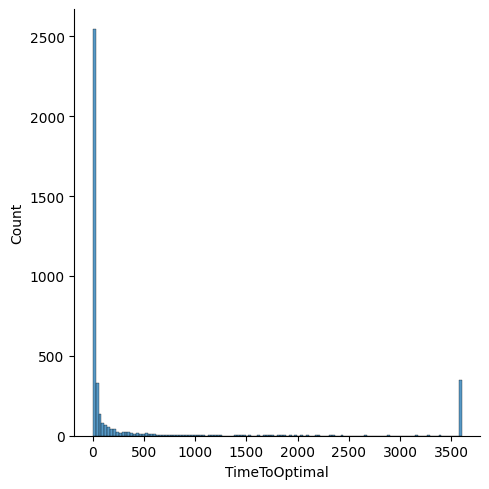

In [66]:
sns.displot(df_optimal, x="TimeToOptimal")

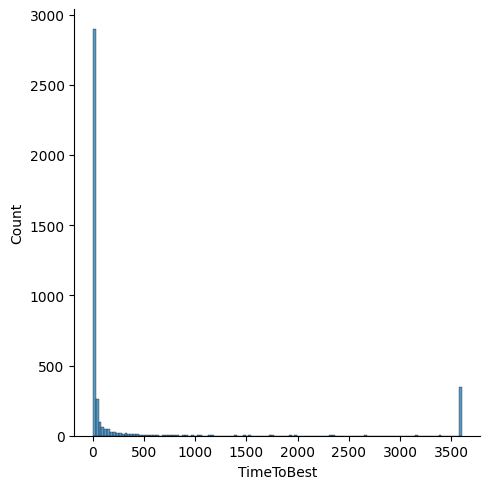

In [67]:
sns.displot(df_optimal, x="TimeToBest")

# Par expérience

In [68]:
def g(group):
    return group.loc[group["ObjVal"] == group["ObjVal"].min(), "TimeToBest"].min()

In [69]:
df_group_best = df_optimal.reset_index()
df_group_best = df_group_best.groupby("Exp").apply(g)
df_group_best = df_group_best.rename("TimeToBest")

In [70]:
df_group_optimal = df_optimal.reset_index()
df_group_optimal = df_group_optimal.groupby("Exp").max()["TimeToOptimal"]

In [79]:
df_group = pd.concat([df_group_best, df_group_optimal], axis=1)
df_group

,TimeToBest,TimeToOptimal
Exp,,
results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId_0_K_1_MoId_0_GroupSize_2_Group_0_MiId_0_N_10_SameAlt_True_DId_0_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_0_McId_0_Id_0_Path_False_PId_0_It_0,0.0,0.02
results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId_0_K_1_MoId_0_GroupSize_2_Group_0_MiId_0_N_20_SameAlt_True_DId_0_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_0_McId_0_Id_0_Path_False_PId_0_It_0,0.0,0.21
results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId_0_K_1_MoId_0_GroupSize_2_Group_0_MiId_0_N_30_SameAlt_True_DId_0_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_0_McId_0_Id_0_Path_False_PId_0_It_0,0.0,1.25
results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId_0_K_1_MoId_0_GroupSize_2_Group_0_MiId_0_N_40_SameAlt_True_DId_0_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_0_McId_0_Id_0_Path_False_PId_0_It_0,0.0,1.99
results/time_per_it_gurobi_3/M_3_Ntr_100_AtrId_0_K_1_MoId_0_GroupSize_2_Group_0_MiId_0_N_50_SameAlt_True_DId_0_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_0_McId_0_Id_0_Path_False_PId_0_It_0,1.0,20.28
...,...,...
results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId_9_K_3_MoId_9_GroupSize_6_Group_0_MiId_9_N_10_SameAlt_True_DId_9_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_9_McId_9_Id_0_Path_False_PId_9_It_0,0.0,1.29
results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId_9_K_3_MoId_9_GroupSize_6_Group_0_MiId_9_N_20_SameAlt_True_DId_9_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_9_McId_9_Id_0_Path_False_PId_9_It_0,1.0,24.90
results/time_per_it_gurobi_3/M_5_Ntr_100_AtrId_9_K_3_MoId_9_GroupSize_6_Group_0_MiId_9_N_30_SameAlt_True_DId_9_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_9_McId_9_Id_0_Path_False_PId_9_It_0,91.0,3600.00


## Plot

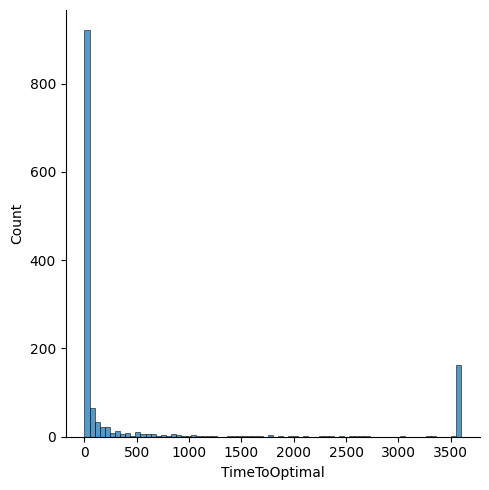

In [72]:
sns.displot(df_group, x="TimeToOptimal")

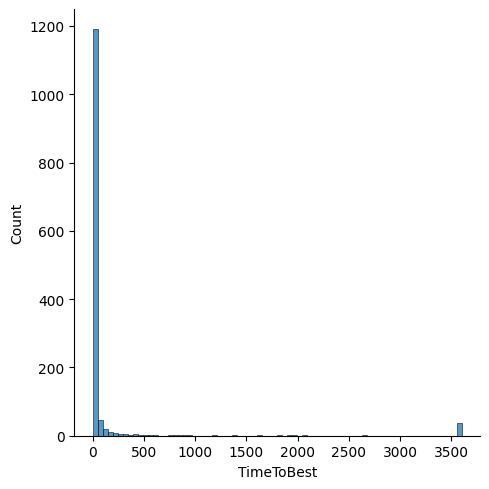

In [73]:
import tikzplotlib  # pyright: ignore[reportMissingTypeStubs]

sns.displot(df_group, x="TimeToBest", )
tikzplotlib.save("mytikz.tex", standalone=True)

In [74]:
float(percentileofscore(df_group["TimeToBest"], 120))
# df_group["TimeToBest"].quantile(0.95)

92.37037037037037

# Cas extrêmes

## Cas 1

In [75]:
locale.setlocale(locale.LC_ALL, "en_US.UTF-8")
results = glt.parse(
    "results/time_per_it_gurobi_2/M_3_Ntr_100_AtrId_1_K_2_MoId_1_GroupSize_2_Group_0_MiId_1_N_50_SameAlt_True_DId_1_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_1_McId_1_Id_0_Path_False_PId_1_It_0_0.json"
)

default_run = results.progress()

fig = go.Figure()
fig.add_trace(
    go.Scatter(x=default_run["Time"], y=default_run["Incumbent"], name="Primal Bound")
)
fig.add_trace(
    go.Scatter(
        x=default_run["Time"],
        y=default_run["BestBd"],
        fill="tonexty",
        name="Dual Bound",
    )
)
fig.update_xaxes(title_text="Runtime")
fig.update_yaxes(title_text="Objective function value")

In [76]:
locale.setlocale(locale.LC_ALL, "en_US.UTF-8")
results = glt.parse(
    "results/time_per_it_gurobi_2/M_3_Ntr_100_AtrId_1_K_2_MoId_1_GroupSize_2_Group_0_MiId_1_N_50_SameAlt_True_DId_1_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_1_McId_1_Id_0_Path_False_PId_1_It_0_1.json"
)

default_run = results.progress()

fig = go.Figure()
fig.add_trace(
    go.Scatter(x=default_run["Time"], y=default_run["Incumbent"], name="Primal Bound")
)
fig.add_trace(
    go.Scatter(
        x=default_run["Time"],
        y=default_run["BestBd"],
        fill="tonexty",
        name="Dual Bound",
    )
)
fig.update_xaxes(title_text="Runtime")
fig.update_yaxes(title_text="Objective function value")
fig.show()

## Cas 2

In [77]:
locale.setlocale(locale.LC_ALL, "en_US.UTF-8")
results = glt.parse(
    "results/time_per_it_gurobi_2/M_3_Ntr_100_AtrId_7_K_3_MoId_7_GroupSize_4_Group_0_MiId_7_N_20_SameAlt_True_DId_7_Method_mip_Config_0_Mie_False_MieConfig_None_MieId_7_McId_7_Id_0_Path_False_PId_7_It_0_5.json"
)

default_run = results.progress()

fig = go.Figure()
fig.add_trace(
    go.Scatter(x=default_run["Time"], y=default_run["Incumbent"], name="Primal Bound")
)
fig.add_trace(
    go.Scatter(
        x=default_run["Time"],
        y=default_run["BestBd"],
        fill="tonexty",
        name="Dual Bound",
    )
)
fig.update_xaxes(title_text="Runtime")
fig.update_yaxes(title_text="Objective function value")
fig.show()

In [78]:
# default_run = results.progress()

# fig = go.Figure()
# fig.add_trace(
#     go.Scatter(x=default_run["Time"], y=default_run["Incumbent"], name="Primal Bound")
# )
# fig.add_trace(
#     go.Scatter(
#         x=default_run["Time"],
#         y=default_run["BestBd"],
#         fill="tonexty",
#         name="Dual Bound",
#     )
# )
# fig.update_xaxes(title_text="Runtime")
# fig.update_yaxes(title_text="Objective function value")
# fig.show()